# Analiza zbioru LandCover.ai

In [ ]:
import sys

sys.path.append("../")

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # type: ignore
from matplotlib.colors import ListedColormap
from PIL import Image

from torch_datasets.landcover_dataset import LandcoverDataset

sns.set_style("whitegrid")

In [2]:
DATA_DIR = Path("../data/landcover.ai.v1")

In [3]:
data_val = LandcoverDataset(image_dir=DATA_DIR / "output",
                                          split_file=DATA_DIR / "val.txt",
                                          return_meta=True)
data_train = LandcoverDataset(image_dir=DATA_DIR / "output",
                                          split_file=DATA_DIR / "train.txt",
                                          return_meta=True)
data_test = LandcoverDataset(image_dir=DATA_DIR / "output",
                                          split_file=DATA_DIR / "test.txt",
                                          return_meta=True)

In [6]:
np.random.seed(1)
sample_size = 2000

sample_train = [data_train[i] for i in np.random.choice(range(len(data_train)), sample_size, replace=False)]

## Przykładowe dane


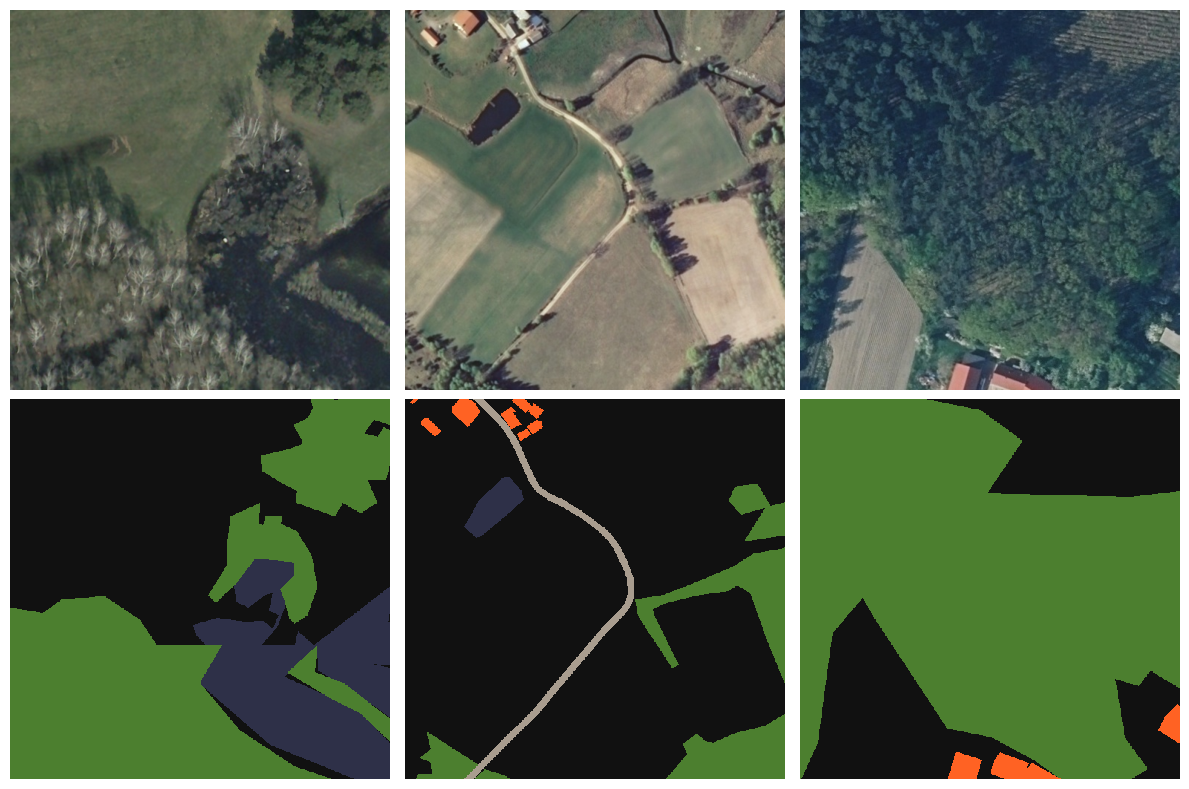

In [7]:
np.random.seed(20)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
img_count = axes.size // 2
mask_cols = ['#111111', '#ff6223', '#4c7f2f', '#2e3048', '#a99d8f']
random_pics_id = np.random.randint(0, len(data_val), img_count)
for i, img_id in enumerate(random_pics_id):
    image = Image.open(sample_train[img_id]["path"])
    axes[i].imshow(image)
    axes[i].axis("off")

    axes[i + img_count].imshow(sample_train[img_id]["mask"], cmap=ListedColormap(mask_cols), vmin=0, vmax=4, interpolation='nearest')
    axes[i + img_count].axis("off")
plt.tight_layout()
plt.show()

## Ogólne statystyki
Wszystkie obrazy są $512 \times 512$.

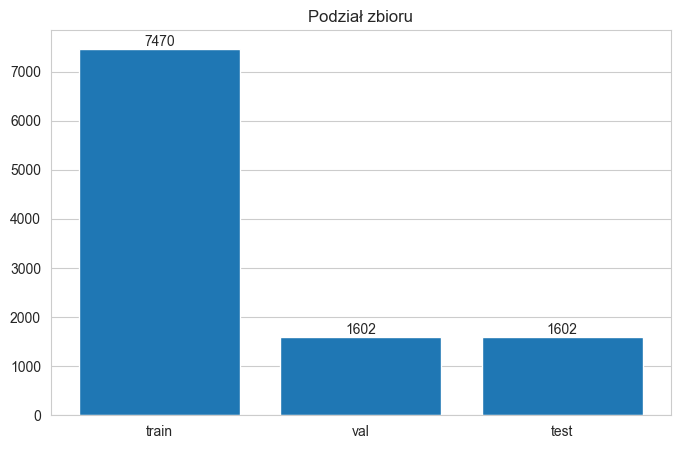

In [123]:
IMG_SIZE = 512*512

lengths = [len(data_train), len(data_val), len(data_test)]
captions = ["train", "val", "test"]
fig, ax = plt.subplots(figsize=(8,5))
p = ax.bar(captions, lengths)
ax.bar_label(p, label_type="edge")
ax.set_title("Podział zbioru")
ax.grid(axis='x')
plt.show()

In [ ]:
def category_stats(data: list, thresholds: list = None) -> tuple[np.ndarray, np.ndarray]: # type: ignore
    if thresholds is None:
        thresholds = [0.95, 0.99, 1]    
    pixel_count = np.zeros(5)
    one_cat_count = np.zeros(len(thresholds))

    for item in data:
        mask = np.asarray(item["mask"]).ravel()
        count = np.bincount(mask.astype(int))
        for i in range(len(count)):
            pixel_count[i] += count[i]
        ratio = max(count) / IMG_SIZE
        for i in range(len(thresholds) - 1, -1, -1):
            if ratio >= thresholds[i]:
                one_cat_count[i] += 1
    return pixel_count, one_cat_count

cat_count = {}
one_cat_count = {}
cat_count['train'], one_cat_count['train'] = category_stats(sample_train) # data_train takes too long
cat_count['val'], one_cat_count['val'] = category_stats(data_val) # type: ignore
cat_count['test'], one_cat_count['test'] = category_stats(data_test) # type: ignore

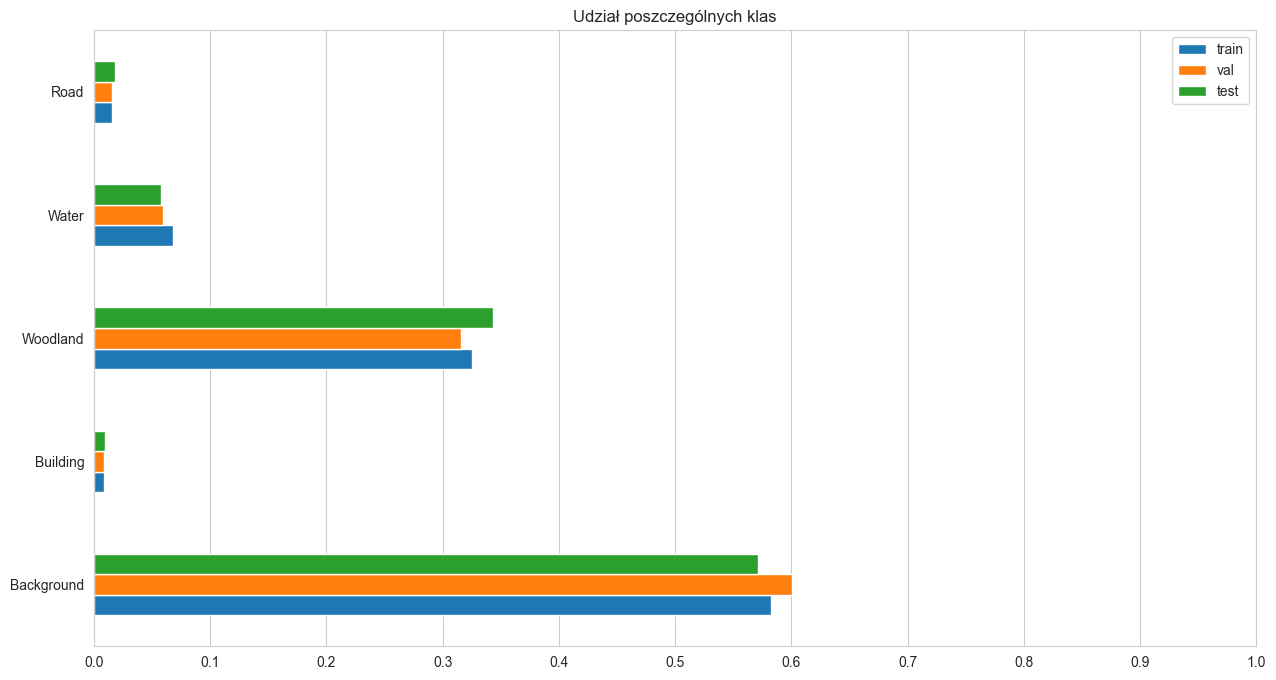

In [ ]:
categories = ["Background", "Building", "Woodland", "Water", "Road"]
df = pd.DataFrame({
    'train': cat_count['train'] / len(sample_train) / IMG_SIZE,
    'val': cat_count['val'] / len(data_val) / IMG_SIZE,
    'test': cat_count['test'] / len(data_test) / IMG_SIZE
}, index=categories)

df.plot(kind='barh', figsize=(15,8), xlim=(0,1), xticks=list(np.arange(0, 1.0001, 0.1))) # type: ignore
plt.title("Udział poszczególnych klas")
plt.grid(axis='y')
plt.show()

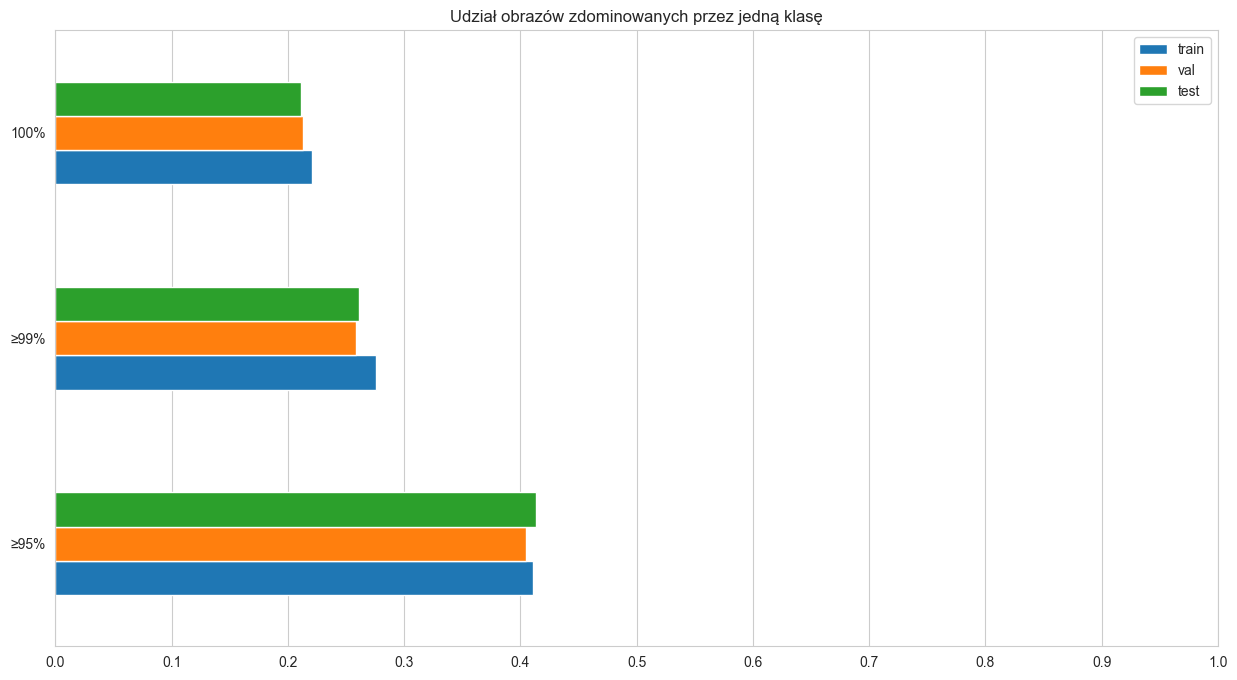

In [ ]:
categories = ['≥95%', '≥99%', '100%']
df = pd.DataFrame({
    'train': one_cat_count['train'] / len(sample_train),
    'val': one_cat_count['val'] / len(data_val),
    'test': one_cat_count['test'] / len(data_test)
}, index=categories)

df.plot(kind='barh', figsize=(15, 8), xlim=(0,1), xticks=list(np.arange(0, 1.0001, 0.1))) # type: ignore
plt.title("Udział obrazów zdominowanych przez jedną klasę")
plt.grid(axis='y')
plt.show()

## Średnia i odchylenie standardowe pikseli (train)

In [127]:
from tqdm import tqdm

mean_acc = np.zeros(3)
var_acc = np.zeros(3)
n = 0

for i in tqdm(range(len(sample_train))):
    image = np.asarray(sample_train[i]["image"])
    mean_acc += image.mean(axis=(1, 2))
    var_acc += image.var(axis=(1, 2))
    n += 1

pixel_mean = mean_acc / n
pixel_std = np.sqrt(var_acc / n)

print(f"Średnia (R, G, B): {pixel_mean}")
print(f"Std     (R, G, B): {pixel_std}")

100%|██████████| 2000/2000 [00:13<00:00, 147.04it/s]

Średnia (R, G, B): [0.3651488  0.39352093 0.3404547 ]
Std     (R, G, B): [0.10747509 0.09497052 0.07975048]


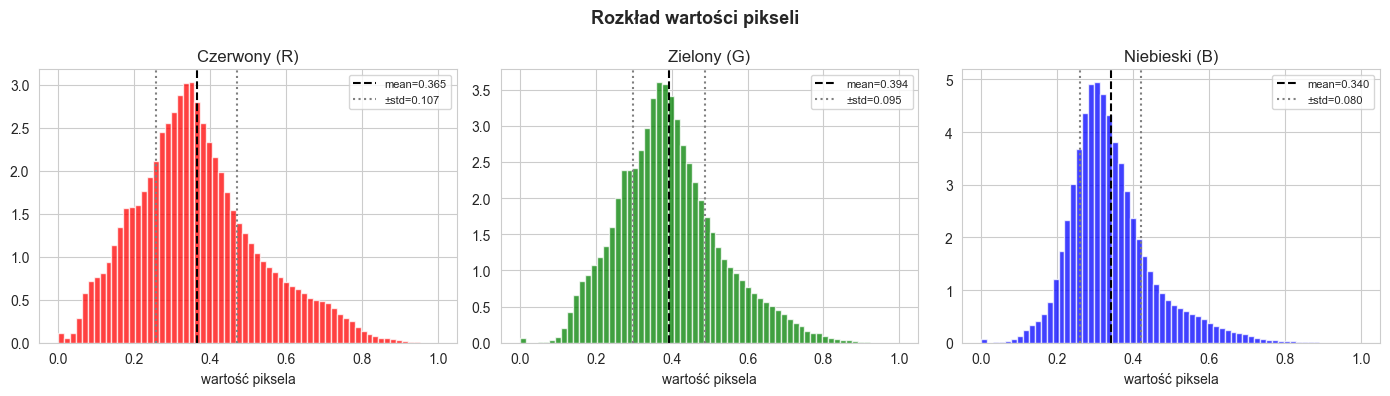

In [128]:
all_images = np.stack([item["image"] for item in sample_train])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    "Rozkład wartości pikseli", fontsize=13, fontweight="bold"
)
channel_names = ["Czerwony (R)", "Zielony (G)", "Niebieski (B)"]
colors = ["red", "green", "blue"]

for c, (ax, name, col) in enumerate(zip(axes, channel_names, colors, strict=False)):
    ax.hist(all_images[:, c, :, :].ravel(), color=col, bins=64, alpha=0.75, density=True)
    ax.axvline(
        pixel_mean[c], color="black", linestyle="--", label=f"mean={pixel_mean[c]:.3f}"
    )
    ax.axvline(
        pixel_mean[c] + pixel_std[c],
        color="gray",
        linestyle=":",
        label=f"±std={pixel_std[c]:.3f}",
    )
    ax.axvline(pixel_mean[c] - pixel_std[c], color="gray", linestyle=":")
    ax.set_title(name)
    ax.set_xlabel("wartość piksela")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Wizualizacja tranformacji

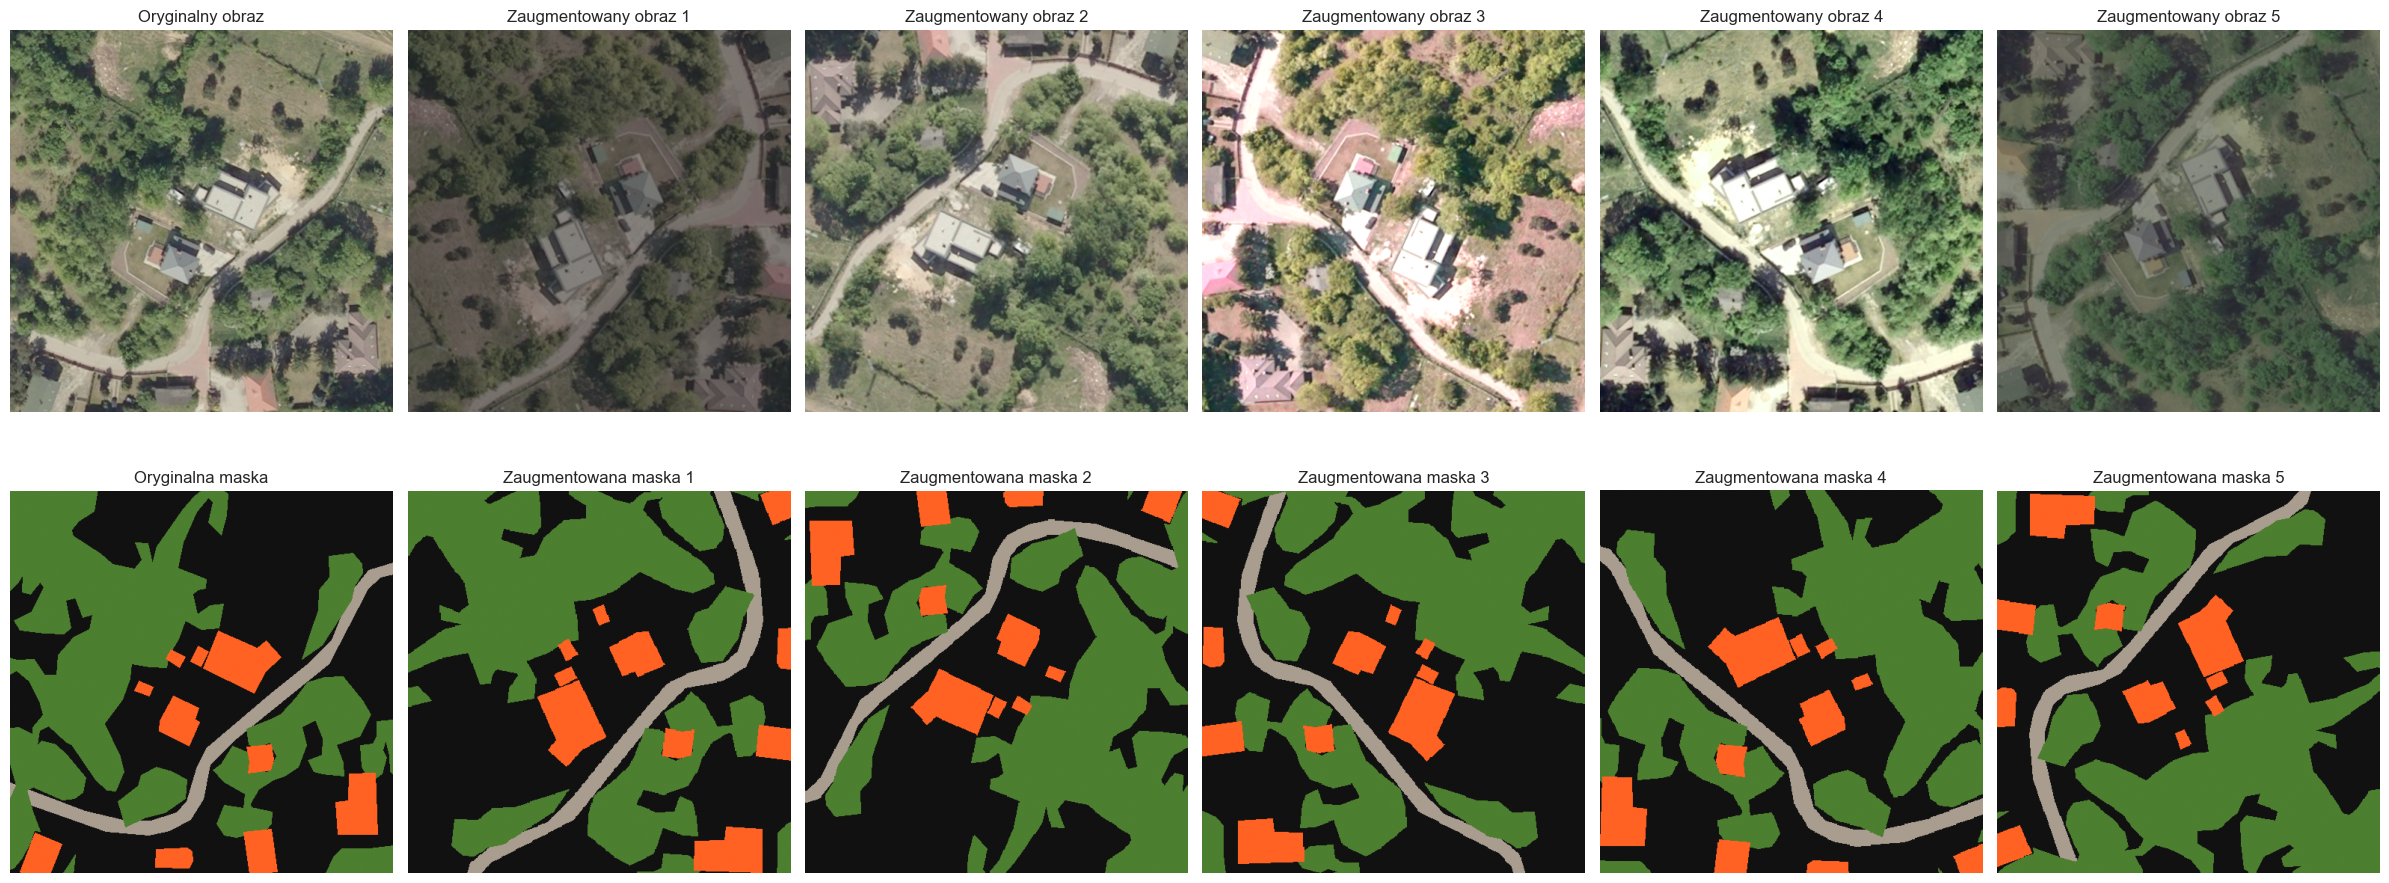

In [ ]:
import torch

from torch_datasets.transforms import TrainTransform

random.seed(4)

rng_idx = random.randint(0, len(data_train) - 1)
num_examples=5
img_tensor = data_train[rng_idx]["image"]
mask_tensor = data_train[rng_idx]["mask"]

transform = TrainTransform()

fig, axes = plt.subplots(2, num_examples + 1, figsize=(4 * (num_examples + 1), 10))

axes[0, 0].imshow(img_tensor.permute(1, 2, 0).numpy())
axes[0, 0].set_title("Oryginalny obraz")
axes[0, 0].axis('off')

axes[1, 0].imshow(mask_tensor, cmap=ListedColormap(mask_cols), vmin=0, vmax=4) 
axes[1, 0].set_title("Oryginalna maska")
axes[1, 0].axis('off')

mean = torch.tensor([0.3651488, 0.39352093, 0.3404547]).view(3, 1, 1)
std = torch.tensor([0.10747509, 0.09497052, 0.07975048]).view(3, 1, 1)

for i in range(1, num_examples + 1):

    aug_img, aug_mask = transform(img_tensor, mask_tensor.unsqueeze(0))
    
    denorm_img = aug_img * std + mean
    denorm_img = torch.clamp(denorm_img, 0, 1) 
    
    img_show = denorm_img.permute(1, 2, 0).numpy()
    mask_show = aug_mask.squeeze(0).numpy()
    
    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f"Zaugmentowany obraz {i}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask_show, cmap=ListedColormap(mask_cols), vmin=0, vmax=4)
    axes[1, i].set_title(f"Zaugmentowana maska {i}")
    axes[1, i].axis('off')
    
plt.tight_layout()
plt.show()